### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [117]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow import io, image, data
from tensorflow.keras import Model, layers, utils, callbacks, optimizers, losses
from tensorflow.keras.applications.inception_v3 import InceptionV3

In [5]:
from functools import partial
import albumentations as A

### Step 2: Constant

In [6]:
AUTO = tf.data.experimental.AUTOTUNE
TRAIN_FOLD = './data/dog_breed_classification/train/'
IMG_HEIGH = 128
IMG_WIDTH = 128
IMG_CHANNEL = 3
BATCH_SIZE = 32

### Step 3: Load Data

In [183]:
df = pd.read_csv('./data/dog_breed_classification/labels.csv')

In [184]:
df['id'] = df['id'].map(lambda x: x+'.jpg')

In [185]:
df.shape

(10222, 2)

In [186]:
df.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07.jpg,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97.jpg,dingo
2,001cdf01b096e06d78e9e5112d419397.jpg,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d.jpg,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62.jpg,golden_retriever


### Step 4: Exploaring Data

#### Target Distribution

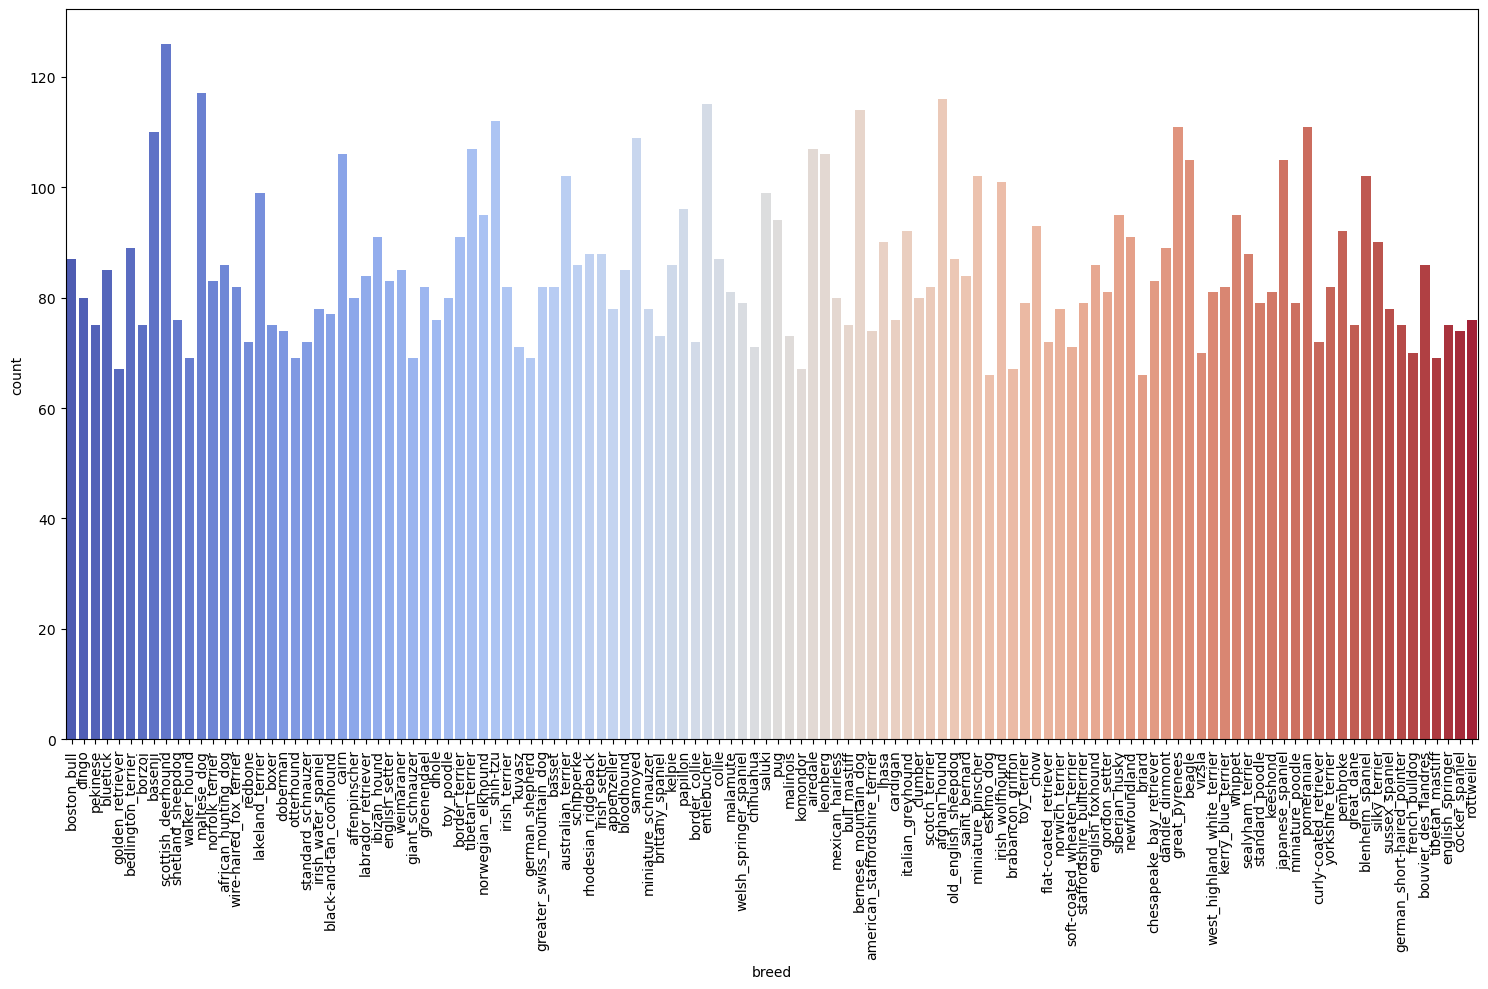

In [11]:
plt.figure(figsize=(15, 10))
sns.countplot(x='breed', data=df, palette='coolwarm')
plt.xticks(rotation=90)
plt.tight_layout()

#### Show Image

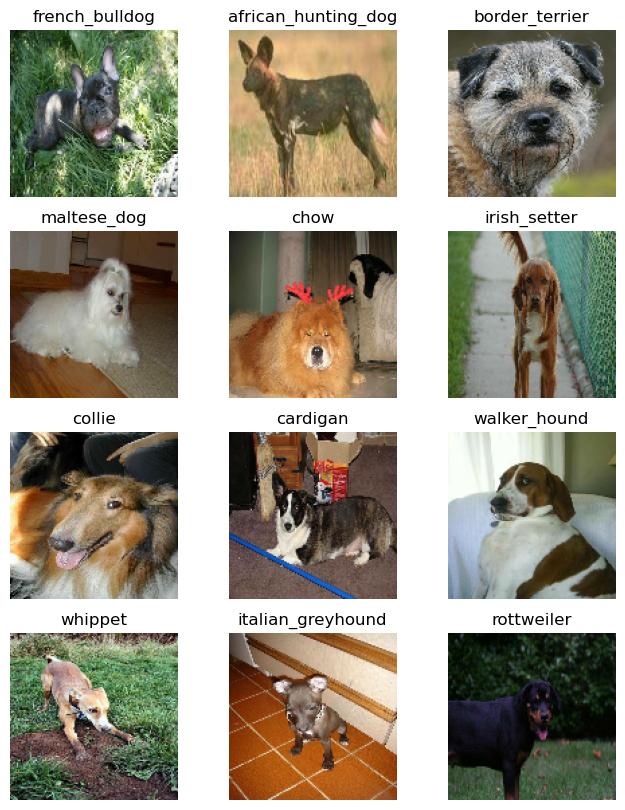

In [12]:
plt.figure(figsize=(8, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)
    k = np.random.randint(0, len(df))
    img_id = df.loc[k, 'id']
    target = df.loc[k, 'breed']
    img = io.read_file(f'{TRAIN_FOLD}{img_id}')
    img = image.decode_jpeg(img)
    img = image.resize(img, (125, 125))
    plt.imshow(img/255.0)
    plt.title(target)
    plt.axis('off')

### Step 5: Preparing Data

#### Label Encode

In [187]:
le = LabelEncoder()

In [188]:
df['breed_id'] = le.fit_transform(df['breed'])

In [189]:
df.head()

,id,breed,breed_id
0,000bec180eb18c7604dcecc8fe0dba07.jpg,boston_bull,19
1,001513dfcb2ffafc82cccf4d8bbaba97.jpg,dingo,37
2,001cdf01b096e06d78e9e5112d419397.jpg,pekinese,85
3,00214f311d5d2247d5dfe4fe24b2303d.jpg,bluetick,15
4,0021f9ceb3235effd7fcde7f7538ed62.jpg,golden_retriever,49


#### Split Data

In [190]:
train, test = train_test_split(
    df,
    test_size=0.4,
    random_state=42
)

In [191]:
value, test = train_test_split(
    test,
    test_size=0.5,
    random_state=42
)

#### Albumentation

In [192]:
transforms_train = A.Compose(
    [
        A.Resize(IMG_HEIGH, IMG_WIDTH),
        A.VerticalFlip(p=0.2),
        A.HorizontalFlip(p=0.7),
        A.CoarseDropout(p=0.5),
        A.RandomGamma(p=0.5),
        A.RandomBrightnessContrast(p=1)
    ]
)

In [193]:
transforms_value = A.Compose(
    [
        A.Resize(IMG_HEIGH, IMG_WIDTH)
    ]
)

#### Build Dataset

In [200]:
def generator(df, img_shape, is_transform):
    def gen():
        for _, row in df.iterrows():
            img = cv2.imread(os.path.join(TRAIN_FOLD, row['id']))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if is_transform:
                img = transforms_train(image=img)['image']
            else:
                img = transforms_value(image=img)['image']
            img = img.astype('float32') / 255.0
            yield img, row['breed_id']
            
    return data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.uint8)
        )
    )

In [201]:
def get_generator(df, img_shape, batch_size, is_transform=True, is_shuffle=True):
    gen = generator(df, img_shape, is_transform)
    gen = gen.map(
        lambda x, y: (x, tf.one_hot(y, len(le.classes_))),
    )
    if is_shuffle:
        gen = gen.shuffle(len(df))
    gen = gen.batch(batch_size)
    gen = gen.prefetch(AUTO)
    return gen

In [202]:
train_generator = get_generator(train, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
value_generator = get_generator(value, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_transform=False, is_shuffle=False)
test_generator = get_generator(test, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_transform=False, is_shuffle=False)

In [203]:
for img, label in test_generator.take(1):
  print(img.shape, label.shape)

(32, 128, 128, 3) (32, 120)


### Step 6: Model Development

#### Build Model

In [204]:
base_model = InceptionV3(
    input_shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL),
    weights='imagenet',
    include_top=False
)

In [205]:
base_model.trainable = False

In [206]:
base_model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_470 (Conv2D)           │ (None, 63, 63, 32)        │             864 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_480       │ (None, 63, 63, 32)        │              96 │ conv2d_470[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_470 (Activation)   │ (None, 63, 63, 32)        │               0 │ batch_normalization_480[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_471 (Conv2D)           │ (None, 61, 61, 32)        │           9,216 │ activation_470[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_481       │ (None, 61, 61, 32)        │              96 │ conv2d_471[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_471 (Activation)   │ (None, 61, 61, 32)        │               0 │ batch_normalization_481[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_472 (Conv2D)           │ (None, 61, 61, 64)        │          18,432 │ activation_471[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_482       │ (None, 61, 61, 64)        │             192 │ conv2d_472[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_472 (Activation)   │ (None, 61, 61, 64)        │               0 │ batch_normalization_482[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_20              │ (None, 30, 30, 64)        │               0 │ activation_472[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_473 (Conv2D)           │ (None, 30, 30, 80)        │           5,120 │ max_pooling2d_20[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_483       │ (None, 30, 30, 80)        │             240 │ conv2d_473[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_473 (Activation)   │ (None, 30, 30, 80)        │               0 │ batch_normalization_483[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_474 (Conv2D)           │ (None, 28, 28, 192)       │         138,24

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

In [146]:
last_layer = base_model.get_layer('mixed7')

In [217]:
x = layers.AvgPool2D(2)(base_model.output)
x = layers.Flatten()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.BatchNormalization()(x)

outputs = layers.Dense(120, activation='softmax')(x)

In [218]:
model = Model(base_model.input, outputs)

In [219]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_470 (Conv2D)           │ (None, 63, 63, 32)        │             864 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_480       │ (None, 63, 63, 32)        │              96 │ conv2d_470[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_470 (Activation)   │ (None, 63, 63, 32)        │               0 │ batch_normalization_480[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_471 (Conv2D)           │ (None, 61, 61, 32)        │           9,216 │ activation_470[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_481       │ (None, 61, 61, 32)        │              96 │ conv2d_471[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_471 (Activation)   │ (None, 61, 61, 32)        │               0 │ batch_normalization_481[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_472 (Conv2D)           │ (None, 61, 61, 64)        │          18,432 │ activation_471[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_482       │ (None, 61, 61, 64)        │             192 │ conv2d_472[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_472 (Activation)   │ (None, 61, 61, 64)        │               0 │ batch_normalization_482[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_20              │ (None, 30, 30, 64)        │               0 │ activation_472[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_473 (Conv2D)           │ (None, 30, 30, 80)        │           5,120 │ max_pooling2d_20[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_483       │ (None, 30, 30, 80)        │             240 │ conv2d_473[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_473 (Activation)   │ (None, 30, 30, 80)        │               0 │ batch_normalization_483[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_474 (Conv2D)           │ (None, 28, 28, 192)       │         138,24

 Total params: 24,595,096 (93.82 MB)

 Trainable params: 2,788,728 (10.64 MB)

 Non-trainable params: 21,806,368 (83.18 MB)

#### Model Compile

In [220]:
optimizer = optimizers.Adam(
    learning_rate=0.01,
    clipnorm=1.0
)

In [221]:
model.compile(
    optimizer=optimizer,
    loss=losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [222]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    mode='min'
)

In [223]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.5,
    verbose=1
)

#### Training Model

In [224]:
history = model.fit(
    train_generator,
    validation_data=value_generator,
    verbose=2,
    epochs=50,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/50
192/192 - 84s - 436ms/step - accuracy: 0.0538 - loss: 4.6417 - val_accuracy: 0.1429 - val_loss: 3.8144 - learning_rate: 0.0100
Epoch 2/50
192/192 - 73s - 382ms/step - accuracy: 0.1040 - loss: 3.8638 - val_accuracy: 0.2197 - val_loss: 3.0833 - learning_rate: 0.0100
Epoch 3/50
192/192 - 73s - 381ms/step - accuracy: 0.1306 - loss: 3.6261 - val_accuracy: 0.2691 - val_loss: 2.7653 - learning_rate: 0.0100
Epoch 4/50
192/192 - 72s - 374ms/step - accuracy: 0.1485 - loss: 3.5081 - val_accuracy: 0.2862 - val_loss: 2.7937 - learning_rate: 0.0100
Epoch 5/50
192/192 - 73s - 382ms/step - accuracy: 0.1525 - loss: 3.4814 - val_accuracy: 0.3097 - val_loss: 2.6485 - learning_rate: 0.0100
Epoch 6/50
192/192 - 74s - 383ms/step - accuracy: 0.1648 - loss: 3.4443 - val_accuracy: 0.3077 - val_loss: 2.5917 - learning_rate: 0.0100
Epoch 7/50
192/192 - 72s - 378ms/step - accuracy: 0.1738 - loss: 3.3766 - val_accuracy: 0.2911 - val_loss: 2.7583 - learning_rate: 0.0100
Epoch 8/50

Epoch 8: ReduceLROnPla

In [233]:
history_df = pd.DataFrame(history.history) 

In [252]:
history_df['epoch'] = history_df.index+1

In [257]:
accuracy_df = history_df.melt(
    id_vars='epoch',
    value_vars=['accuracy', 'val_accuracy'],
    var_name='type',
)

In [258]:
loss_df = history_df.melt(
    id_vars='epoch',
    value_vars=['loss', 'val_loss'],
    var_name='type'
)

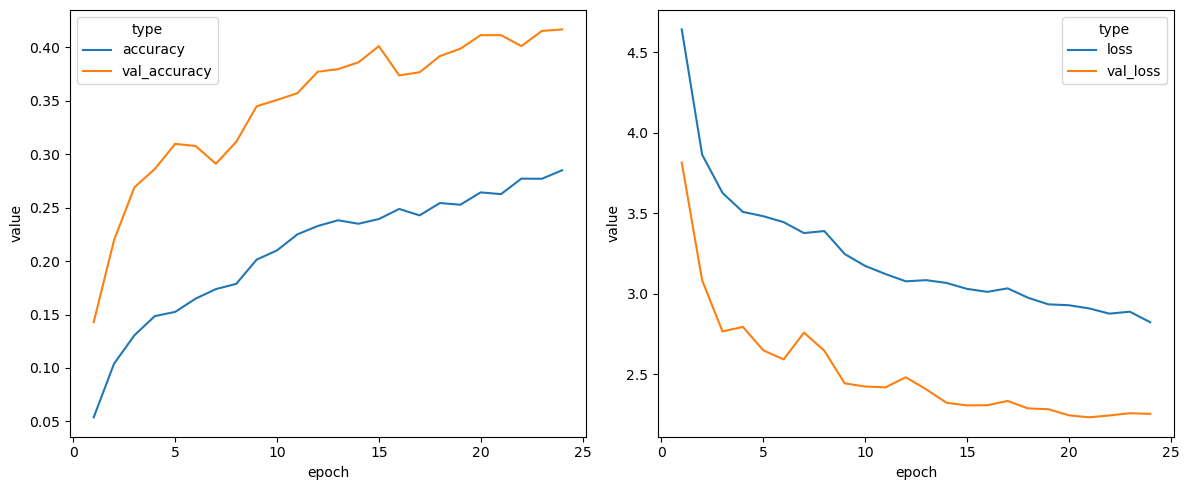

In [260]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.lineplot(x='epoch', y='value', hue='type', data=accuracy_df)
plt.subplot(1, 2, 2)
sns.lineplot(x='epoch', y='value', hue='type', data=loss_df)
plt.tight_layout()

#### Evaluate Model

In [225]:
loss, accuracy = model.evaluate(test_generator, verbose=0)

In [226]:
test_pred = model.predict(test_generator)

64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 336ms/step


In [227]:
print(f'test accuracy: {round(accuracy, 3)}')

test accuracy: 0.405


In [228]:
test['pred'] = le.inverse_transform(np.argmax(test_pred, axis=1))

In [230]:
confusion_matrix = metrics.confusion_matrix(test['breed'], test['pred'])

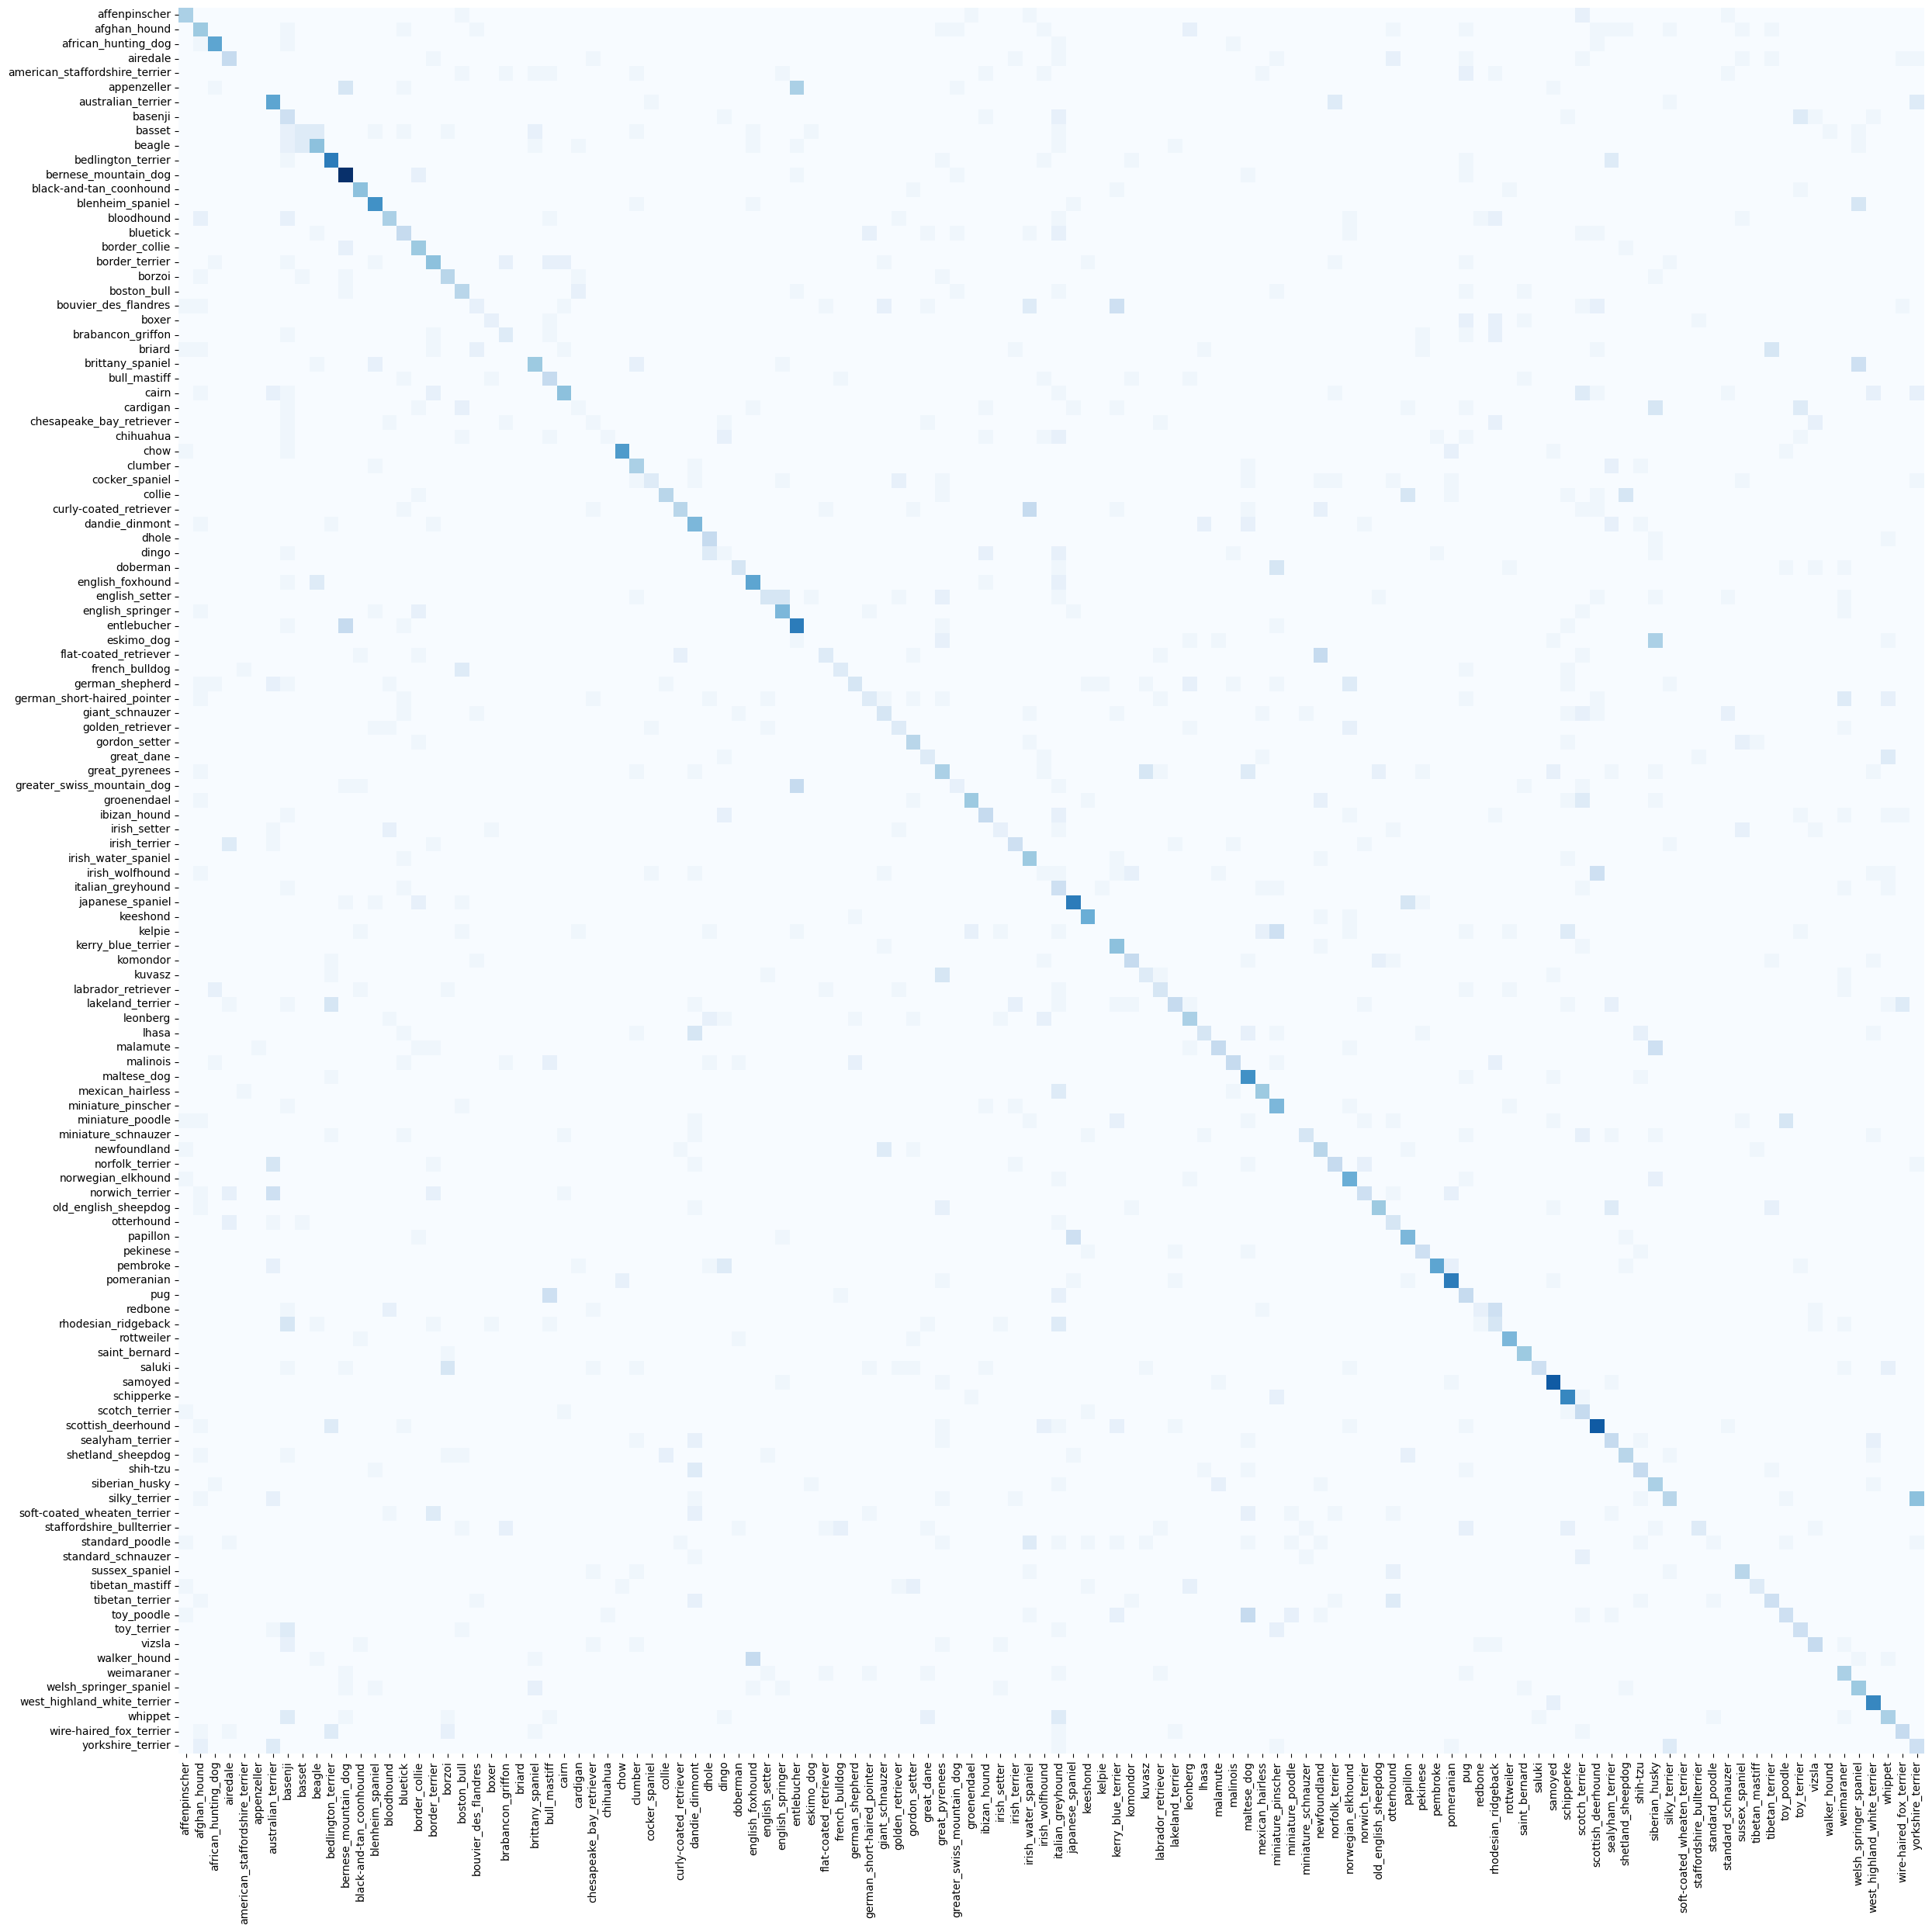

In [231]:
plt.figure(figsize=(25, 25))
sns.heatmap(
    confusion_matrix,
    annot=False,
    cmap=plt.cm.Blues,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar=False
)
plt.tight_layout()